<div style="background: linear-gradient(135deg, #1a3a5c 0%, #2d6a9f 100%); padding: 40px 32px 32px 32px; border-radius: 12px; margin-bottom: 8px;">
  <h1 style="color: #ffffff; font-size: 2.0em; margin: 0 0 6px 0; font-family: 'Segoe UI', sans-serif; font-weight: 700;">
    Week 5, Lesson 10 -- Model Improvement
  </h1>
  <h2 style="color: #a8d4f5; font-size: 1.2em; margin: 0 0 18px 0; font-family: 'Segoe UI', sans-serif; font-weight: 400;">
    Cross-Validation and Random Forests for Formation Classification
  </h2>
  <hr style="border: 1px solid rgba(255,255,255,0.25); margin: 16px 0;">
  <table style="color: #cce4ff; font-family: 'Segoe UI', sans-serif; font-size: 0.95em;">
    <tr>
      <td style="padding: 3px 24px 3px 0;"><strong>Week:</strong></td><td>5 (Lesson 10) -- Model Improvement</td>
      <td style="padding: 3px 24px 3px 32px;"><strong>Duration:</strong></td><td>40 Minutes</td>
    </tr>
    <tr>
      <td style="padding: 3px 24px 3px 0;"><strong>Track:</strong></td><td>Petroleum Engineers &amp; Geoscientists</td>
      <td style="padding: 3px 24px 3px 32px;"><strong>Audience:</strong></td><td>Engineers &amp; Geoscientists</td>
    </tr>
    <tr>
      <td style="padding: 3px 24px 3px 0;"><strong>Instructor:</strong></td><td>Dr. Daniel Wamriew</td>
      <td style="padding: 3px 24px 3px 32px;"><strong>Contact:</strong></td><td>wamriewdan@gmail.com</td>
    </tr>
  </table>
</div>

<div style="background: #e8f5e9; border-left: 5px solid #2ca87f; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

### How to Use This Notebook

Work through this notebook **from top to bottom**, pressing **Shift + Enter** on each cell to run it.

- **Code cells** contain Python -- run them and read the output carefully.
- **Markdown cells** (white background) contain explanations -- read before running the next cell.
- **Student Activity** cells are marked with `Activity` -- complete these before moving on.
- **Homework** cells are marked with `Homework` -- complete after the session.
- You need **`well_log_data.csv`** in the course `data` folder.

</div>

---
## Table of Contents

1. [Why Improve a Model?](#1-why-improve-a-model)
2. [Holdout Test vs Cross-Validation](#2-holdout-test-vs-cross-validation)
3. [What is a Random Forest?](#3-what-is-a-random-forest)
4. [Prepare the Data](#4-prepare-the-data)
5. [Baseline Decision Tree](#5-baseline-decision-tree)
6. [Cross-Validation](#6-cross-validation)
7. [Train a Random Forest](#7-train-a-random-forest)
8. [Compare Models and Tune Parameters](#8-compare-models-and-tune-parameters)
9. [Feature Importance](#9-feature-importance)
10. [Student Activity](#10-student-activity)
11. [Recap & Homework](#11-recap-homework)

---
## 1. Why Improve a Model?

<div style="background: #f0f7ff; border-left: 5px solid #2d6a9f; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

In Lesson 9 you trained a **Decision Tree** to classify formation type from well logs.
It worked well, but a single tree has one weakness: it can become too confident about small details in the training data.

This lesson improves the workflow in two ways:

| Improvement | Question it answers | Why it matters |
|-------------|---------------------|----------------|
| **Cross-validation** | Is the score stable, or did we get lucky with one split? | Gives a more reliable estimate of performance |
| **Random Forest** | Can many trees vote together better than one tree? | Usually improves accuracy and reduces overfitting |

A good ML engineer does not ask only, **"What score did I get?"**
They ask, **"Can I trust this score on new wells?"**

</div>

---
## 2. Holdout Test vs Cross-Validation

<div style="background: #f0f7ff; border-left: 5px solid #2d6a9f; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

In Lessons 8 and 9 we used one **train/test split**:

```
80% training data  --> model learns
20% test data      --> model is evaluated once
```

That is useful, but the result depends on which rows landed in the test set.

**Cross-validation** repeats the idea several times:

| Fold | Train on | Validate on |
|------|----------|-------------|
| 1 | 80% of rows | first 20% |
| 2 | 80% of rows | second 20% |
| 3 | 80% of rows | third 20% |
| 4 | 80% of rows | fourth 20% |
| 5 | 80% of rows | fifth 20% |

The final result is the **mean score** and the **spread** across folds.
Low spread means the model is stable. High spread means performance depends strongly on the data split.

</div>

---
## 3. What is a Random Forest?

<div style="background: #f0f7ff; border-left: 5px solid #2d6a9f; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

A Random Forest is an **ensemble**: many Decision Trees trained with slight differences, then combined by voting.

For classification:

```
Tree 1 predicts Reservoir_1
Tree 2 predicts Reservoir_1
Tree 3 predicts Transition
Tree 4 predicts Reservoir_1
Tree 5 predicts Reservoir_2

Final Random Forest prediction = Reservoir_1  (majority vote)
```

**Why it often improves geological classification:**

- One tree may overreact to noisy log readings; many trees smooth that noise
- Each tree sees a different sample of rows and features
- The final vote is usually more stable than a single tree
- Feature importance is still available, so the model remains interpretable enough for engineering discussion

</div>

---
## 4. Prepare the Data

We use the same well log dataset and the same five input features from Lesson 9.
This lets us compare the models fairly: same data, same target, better workflow.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries loaded.")

Libraries loaded.


In [4]:
# Load and clean data
# This path works when the notebook is run from the notebooks folder.
df = pd.read_csv("well_log_data.csv")

log_cols = ["GR_API", "NPHI_frac", "RHOB_gcc", "RT_ohmm", "SW_frac"]
df[log_cols] = df.groupby("Well_ID")[log_cols].ffill()
df[log_cols] = df.groupby("Well_ID")[log_cols].bfill()

print("Shape:", df.shape)
print("Wells:", list(df["Well_ID"].unique()))
print("Missing log values remaining:", df[log_cols].isna().sum().sum())
print("\nFormation counts:")
print(df["Formation"].value_counts())

df.head()

Shape: (720, 8)
Wells: ['Well_A', 'Well_B', 'Well_C', 'Well_D']
Missing log values remaining: 0

Formation counts:
Formation
Reservoir_1    240
Reservoir_2    192
Basement       112
Shale_Cap       96
Transition      80
Name: count, dtype: int64


,Well_ID,Depth_m,Formation,GR_API,NPHI_frac,RHOB_gcc,RT_ohmm,SW_frac
0,Well_A,2000.0,Shale_Cap,138.0,0.142,2.512,3.78,0.977
1,Well_A,2000.5,Shale_Cap,131.9,0.041,2.467,4.67,0.953
2,Well_A,2001.0,Shale_Cap,130.6,0.169,2.460,3.62,0.986
3,Well_A,2001.5,Shale_Cap,128.3,0.107,2.510,5.52,0.927
4,Well_A,2002.0,Shale_Cap,120.5,0.162,2.460,2.39,0.980


In [5]:
# Features (X) and target (y)
feature_cols = ["GR_API", "NPHI_frac", "RHOB_gcc", "RT_ohmm", "SW_frac"]
X = df[feature_cols]
y = df["Formation"]

class_order = ["Shale_Cap", "Reservoir_1", "Transition", "Reservoir_2", "Basement"]

# Keep one final holdout test set for a fair final comparison
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training rows : {len(X_train)}")
print(f"Test rows     : {len(X_test)}")
print("\nTraining class balance:")
print(y_train.value_counts())

Training rows : 576
Test rows     : 144

Training class balance:
Formation
Reservoir_1    192
Reservoir_2    154
Basement        89
Shale_Cap       77
Transition      64
Name: count, dtype: int64


---
## 5. Baseline Decision Tree

Before improving a model, always create a **baseline**.
Our baseline is the same type of model from Lesson 9: one Decision Tree with `max_depth=4`.

In [6]:
# Baseline model from Lesson 9
baseline_tree = DecisionTreeClassifier(max_depth=4, random_state=42)
baseline_tree.fit(X_train, y_train)

tree_train_pred = baseline_tree.predict(X_train)
tree_test_pred  = baseline_tree.predict(X_test)

tree_train_acc = accuracy_score(y_train, tree_train_pred)
tree_test_acc  = accuracy_score(y_test, tree_test_pred)

print("Baseline Decision Tree")
print(f"Training accuracy : {tree_train_acc:.3f}")
print(f"Test accuracy     : {tree_test_acc:.3f}")
print(f"Train-test gap    : {tree_train_acc - tree_test_acc:.3f}")

Baseline Decision Tree
Training accuracy : 0.858
Test accuracy     : 0.771
Train-test gap    : 0.087


In [7]:
print("Decision Tree classification report:")
print(classification_report(y_test, tree_test_pred, labels=class_order, target_names=class_order))

Decision Tree classification report:
              precision    recall  f1-score   support

   Shale_Cap       1.00      1.00      1.00        19
 Reservoir_1       0.70      0.54      0.61        48
  Transition       1.00      1.00      1.00        16
 Reservoir_2       0.55      0.71      0.62        38
    Basement       1.00      1.00      1.00        23

    accuracy                           0.77       144
   macro avg       0.85      0.85      0.85       144
weighted avg       0.78      0.77      0.77       144



---
## 6. Cross-Validation

Now we evaluate the Decision Tree more carefully using 5-fold cross-validation.

We use `StratifiedKFold`, which keeps the formation proportions similar in every fold.
This is important because the classes are not perfectly balanced.

In [8]:
# 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_cv_scores = cross_val_score(cv_tree, X_train, y_train, cv=cv, scoring="accuracy")

print("Decision Tree cross-validation accuracy:")
for i, score in enumerate(tree_cv_scores, start=1):
    print(f"  Fold {i}: {score:.3f}")

print(f"\nMean CV accuracy : {tree_cv_scores.mean():.3f}")
print(f"CV spread (std)  : {tree_cv_scores.std():.3f}")

Decision Tree cross-validation accuracy:
  Fold 1: 0.836
  Fold 2: 0.843
  Fold 3: 0.748
  Fold 4: 0.861
  Fold 5: 0.809

Mean CV accuracy : 0.819
CV spread (std)  : 0.040


<div style="background: #fff8e1; border-left: 5px solid #e0a800; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

### Interpreting the CV Result

- If the **test accuracy** and **mean CV accuracy** are close, the model estimate is probably reliable.
- If one fold is much lower than the others, the model may struggle with certain parts of the data.
- If training accuracy is much higher than CV accuracy, the model is likely overfitting.

</div>

---
## 7. Train a Random Forest

A Random Forest trains many trees and lets them vote.
We start with 100 trees and limit depth to keep the model controlled.

In [9]:
forest = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    random_state=42,
    class_weight="balanced"
)
forest.fit(X_train, y_train)

forest_train_pred = forest.predict(X_train)
forest_test_pred  = forest.predict(X_test)

forest_train_acc = accuracy_score(y_train, forest_train_pred)
forest_test_acc  = accuracy_score(y_test, forest_test_pred)

print("Random Forest")
print(f"Training accuracy : {forest_train_acc:.3f}")
print(f"Test accuracy     : {forest_test_acc:.3f}")
print(f"Train-test gap    : {forest_train_acc - forest_test_acc:.3f}")

Random Forest
Training accuracy : 0.913
Test accuracy     : 0.806
Train-test gap    : 0.108


In [10]:
print("Random Forest classification report:")
print(classification_report(y_test, forest_test_pred, labels=class_order, target_names=class_order))

Random Forest classification report:
              precision    recall  f1-score   support

   Shale_Cap       1.00      1.00      1.00        19
 Reservoir_1       0.76      0.60      0.67        48
  Transition       1.00      1.00      1.00        16
 Reservoir_2       0.60      0.76      0.67        38
    Basement       1.00      1.00      1.00        23

    accuracy                           0.81       144
   macro avg       0.87      0.87      0.87       144
weighted avg       0.82      0.81      0.81       144



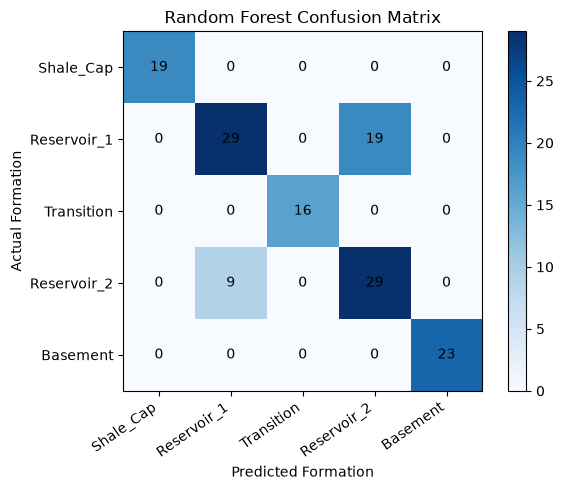

In [11]:
# Confusion matrix for the Random Forest
cm = confusion_matrix(y_test, forest_test_pred, labels=class_order)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm, cmap="Blues")

ax.set_xticks(range(len(class_order)))
ax.set_yticks(range(len(class_order)))
ax.set_xticklabels(class_order, rotation=35, ha="right")
ax.set_yticklabels(class_order)
ax.set_xlabel("Predicted Formation")
ax.set_ylabel("Actual Formation")
ax.set_title("Random Forest Confusion Matrix")

for i in range(len(class_order)):
    for j in range(len(class_order)):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

---
## 8. Compare Models and Tune Parameters

Random Forests have several knobs called **hyperparameters**.
Two useful ones are:

| Parameter | Meaning | Effect |
|-----------|---------|--------|
| `n_estimators` | Number of trees | More trees usually improves stability but takes longer |
| `max_depth` | Maximum depth of each tree | Smaller depth controls overfitting |

We will compare a small set of options using cross-validation.

In [12]:
results = []

for n_trees in [50, 100, 200]:
    for depth in [3, 5, 8, None]:
        model = RandomForestClassifier(
            n_estimators=n_trees,
            max_depth=depth,
            random_state=42,
            class_weight="balanced"
        )
        scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
        results.append({
            "n_estimators": n_trees,
            "max_depth": depth if depth is not None else "None",
            "mean_accuracy": scores.mean(),
            "std_accuracy": scores.std()
        })

results_df = pd.DataFrame(results).sort_values("mean_accuracy", ascending=False).reset_index(drop=True)
results_df

,n_estimators,max_depth,mean_accuracy,std_accuracy
0,50,5,0.831634,0.019921
1,200,8,0.829880,0.022914
2,100,5,0.828141,0.016677
3,100,8,0.826417,0.023741
4,200,5,0.826387,0.016510
5,100,3,0.826372,0.038566
6,200,3,0.826357,0.038623
7,50,3,0.822894,0.032924
8,50,8,0.821184,0.022367
9,50,None,0.817691,0.024088


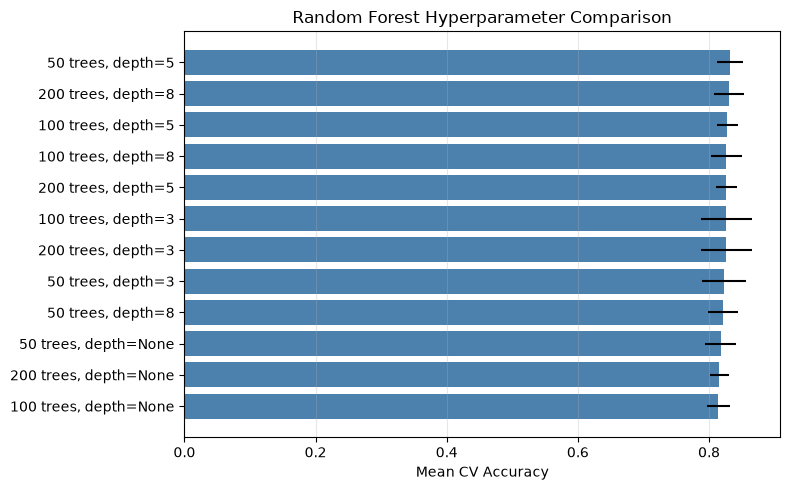

In [13]:
# Visualise the tuning results
plot_df = results_df.copy()
plot_df["model_label"] = plot_df["n_estimators"].astype(str) + " trees, depth=" + plot_df["max_depth"].astype(str)
plot_df = plot_df.sort_values("mean_accuracy")

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(plot_df["model_label"], plot_df["mean_accuracy"], xerr=plot_df["std_accuracy"], color="#2d6a9f", alpha=0.85)
ax.set_xlabel("Mean CV Accuracy")
ax.set_title("Random Forest Hyperparameter Comparison")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

In [14]:
# Train the best model from the tuning table and evaluate on the final test set
best_row = results_df.iloc[0]
best_depth = None if best_row["max_depth"] == "None" else int(best_row["max_depth"])

best_forest = RandomForestClassifier(
    n_estimators=int(best_row["n_estimators"]),
    max_depth=best_depth,
    random_state=42,
    class_weight="balanced"
)
best_forest.fit(X_train, y_train)

best_test_pred = best_forest.predict(X_test)
best_test_acc = accuracy_score(y_test, best_test_pred)

print("Best Random Forest from CV")
print(f"n_estimators : {int(best_row['n_estimators'])}")
print(f"max_depth    : {best_row['max_depth']}")
print(f"Mean CV acc  : {best_row['mean_accuracy']:.3f} +/- {best_row['std_accuracy']:.3f}")
print(f"Final test acc: {best_test_acc:.3f}")

Best Random Forest from CV
n_estimators : 50
max_depth    : 5
Mean CV acc  : 0.832 +/- 0.020
Final test acc: 0.819


---
## 9. Feature Importance

A Random Forest still tells us which logs were most useful for the classification.
The values below are averaged across all trees in the forest.

Random Forest Feature Importance:
  SW_frac       0.3711  ##############
  RHOB_gcc      0.2300  #########
  RT_ohmm       0.1820  #######
  GR_API        0.1217  ####
  NPHI_frac     0.0951  ###


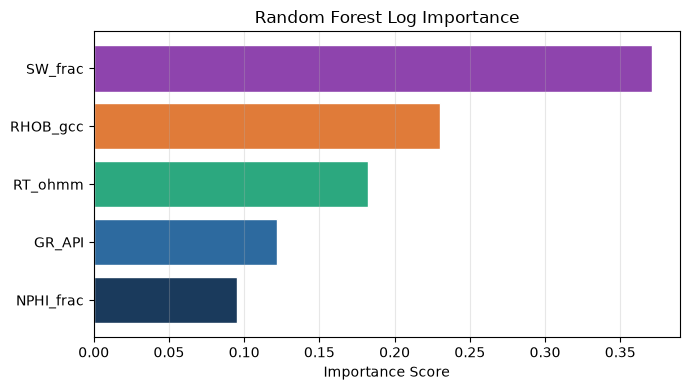

In [15]:
importances = best_forest.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

print("Random Forest Feature Importance:")
for idx in sorted_idx:
    bar = "#" * int(importances[idx] * 40)
    print(f"  {feature_cols[idx]:12s}  {importances[idx]:.4f}  {bar}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(
    [feature_cols[i] for i in sorted_idx][::-1],
    [importances[i] for i in sorted_idx][::-1],
    color=["#1a3a5c", "#2d6a9f", "#2ca87f", "#e07b39", "#8e44ad"],
    edgecolor="white"
)
ax.set_xlabel("Importance Score")
ax.set_title("Random Forest Log Importance")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

<div style="background: #f0f7ff; border-left: 5px solid #2d6a9f; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

### Engineering Interpretation

Feature importance is not just a data science output.
It should be checked against domain knowledge.

For example:

- **GR_API** often separates shale-rich intervals from cleaner reservoir intervals
- **RHOB_gcc** and **NPHI_frac** carry porosity and lithology information
- **RT_ohmm** and **SW_frac** help separate hydrocarbon-bearing and water-bearing intervals

If the model says an unexpected feature dominates, investigate before trusting the result.

</div>

---
## 10. Student Activity

<div style="background: #fff3cd; border-left: 5px solid #ffc107; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

### Activity: Tune `min_samples_leaf`

`min_samples_leaf` controls the minimum number of rows allowed in a final leaf of each tree.
Larger values make the forest smoother and less sensitive to tiny local patterns.

Try `min_samples_leaf = 1, 3, 5, 10` using a Random Forest with:

- `n_estimators=100`
- `max_depth=6`
- `class_weight="balanced"`
- 5-fold cross-validation

Record your results:

| min_samples_leaf | Mean CV accuracy | CV std | Comment |
|------------------|------------------|--------|---------|
| 1 | | | |
| 3 | | | |
| 5 | | | |
| 10 | | | |

**Reflection:** Which value would you choose for a model that must generalise to new wells? Why?

</div>

In [16]:
# Activity -- tune min_samples_leaf
activity_results = []

for leaf_size in [1, 3, 5, 10]:
    activity_model = RandomForestClassifier(
        n_estimators=100,
        max_depth=6,
        min_samples_leaf=leaf_size,
        random_state=42,
        class_weight="balanced"
    )
    scores = cross_val_score(activity_model, X_train, y_train, cv=cv, scoring="accuracy")
    activity_results.append({
        "min_samples_leaf": leaf_size,
        "mean_accuracy": scores.mean(),
        "std_accuracy": scores.std()
    })

activity_df = pd.DataFrame(activity_results)
activity_df

,min_samples_leaf,mean_accuracy,std_accuracy
0,1,0.819460,0.023454
1,3,0.824663,0.022854
2,5,0.821169,0.025031
3,10,0.821169,0.029471


---
## 11. Recap & Homework

<div style="background: #e8f5e9; border-left: 5px solid #2ca87f; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

### What You Learned

| Concept | Meaning |
|---------|---------|
| Baseline model | Simple first model used for comparison |
| Cross-validation | Repeated train/validation splits for a more reliable score |
| CV mean | Average model performance across folds |
| CV standard deviation | How much performance changes across folds |
| Random Forest | Many Decision Trees combined by voting |
| Hyperparameter tuning | Testing model settings before final evaluation |
| Feature importance | Which inputs the model relied on most |

A single score is not enough. A strong ML workflow asks whether the model is **accurate, stable, and explainable**.

</div>

### Homework

Complete the following tasks in the code cells below.

**Task 1 -- Compare Decision Tree Depths**

Use 5-fold cross-validation to compare `DecisionTreeClassifier` models with `max_depth = 2, 4, 6, None`.
Print a table with mean accuracy and standard deviation.

**Task 2 -- Build a Small Random Forest**

Train a Random Forest with only `n_estimators=20` and `max_depth=5`.
Compare its final test accuracy with the best forest from Section 8.
Write one sentence: is the smaller model good enough?

**Task 3 (Engineering) -- Test on One Unseen Well**

Train a Random Forest on all wells except `Well_D`, then test only on `Well_D`.
This is harder than a random split because the model must generalise to an unseen well.
Report accuracy and a classification report.
Write two sentences explaining whether this score is more realistic for field deployment.

In [17]:
# Homework Task 1 -- Compare Decision Tree Depths
# Hint: loop over depths = [2, 4, 6, None]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_tree = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_cv_scores = cross_val_score(cv_tree, X_train, y_train, cv=cv, scoring="accuracy")

print("Decision Tree cross-validation accuracy:")
for i, score in enumerate(tree_cv_scores, start=1):
    print(f"  Fold {i}: {score:.3f}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_cv_scores = cross_val_score(cv_tree, X_train, y_train, cv=cv, scoring="accuracy")

print("Decision Tree cross-validation accuracy:")
for i, score in enumerate(tree_cv_scores, start=1):
    print(f"  Fold {i}: {score:.3f}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_tree = DecisionTreeClassifier(max_depth=6, random_state=42)
tree_cv_scores = cross_val_score(cv_tree, X_train, y_train, cv=cv, scoring="accuracy")

print("Decision Tree cross-validation accuracy:")
for i, score in enumerate(tree_cv_scores, start=1):
    print(f"  Fold {i}: {score:.3f}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_tree = DecisionTreeClassifier(max_depth=None, random_state=42)
tree_cv_scores = cross_val_score(cv_tree, X_train, y_train, cv=cv, scoring="accuracy")

print("Decision Tree cross-validation accuracy:")
for i, score in enumerate(tree_cv_scores, start=1):
    print(f"  Fold {i}: {score:.3f}")


print(f"\nMean CV accuracy : {tree_cv_scores.mean():.3f}")
print(f"CV spread (std)  : {tree_cv_scores.std():.3f}")

Decision Tree cross-validation accuracy:
  Fold 1: 0.707
  Fold 2: 0.722
  Fold 3: 0.661
  Fold 4: 0.722
  Fold 5: 0.643
Decision Tree cross-validation accuracy:
  Fold 1: 0.836
  Fold 2: 0.843
  Fold 3: 0.748
  Fold 4: 0.861
  Fold 5: 0.809
Decision Tree cross-validation accuracy:
  Fold 1: 0.802
  Fold 2: 0.861
  Fold 3: 0.730
  Fold 4: 0.809
  Fold 5: 0.800
Decision Tree cross-validation accuracy:
  Fold 1: 0.750
  Fold 2: 0.765
  Fold 3: 0.704
  Fold 4: 0.739
  Fold 5: 0.757

Mean CV accuracy : 0.743
CV spread (std)  : 0.021


In [18]:
# Homework Task 2 -- Build a Small Random Forest
# Hint: use n_estimators=20, max_depth=5, random_state=42, class_weight="balanced"
small_forest = RandomForestClassifier(
    n_estimators=20,
    max_depth=best_depth,
    random_state=42,
    class_weight="balanced"
)
small_forest.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",20
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 Th

In [26]:
# Homework Task 3 (Engineering) -- Test on One Unseen Well
# Hint:
feature_cols = ["GR_API", "NPHI_frac", "RHOB_gcc", "RT_ohmm", "SW_frac"]
X = df[feature_cols]
y = df["Well_ID"]

class_order = ["Well_A","Well_B","Well_C", "Well_D"]

model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

train_df = df[df["Well_ID"] != "Well_D"]
test_df  = df[df["Well_ID"] == "Well_D"]

print("Model trained!")
print(f"Tree depth (actual): {model.get_depth()}")
print(f"Number of leaves   : {model.get_n_leaves()}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training rows : {len(train_df)}")
print(f"Test rows     : {len(test_df)}")
print("\nClass balance in training set:")
print(train_df.value_counts())
print("\nClass balance in testing set:")
print(train_df.value_counts())

y_pred = model.predict(X_test)


Model trained!
Tree depth (actual): 4
Number of leaves   : 14
Training rows : 540
Test rows     : 180

Class balance in training set:
Well_ID  Depth_m  Formation  GR_API  NPHI_frac  RHOB_gcc  RT_ohmm  SW_frac
Well_A   2000.0   Shale_Cap  138.0   0.142      2.512     3.78     0.977      1
         2000.5   Shale_Cap  131.9   0.041      2.467     4.67     0.953      1
         2001.0   Shale_Cap  130.6   0.169      2.460     3.62     0.986      1
         2001.5   Shale_Cap  128.3   0.107      2.510     5.52     0.927      1
         2002.0   Shale_Cap  120.5   0.162      2.460     2.39     0.980      1
                                                                             ..
Well_C   2072.5   Basement   82.5    0.030      2.689     333.18   0.980      1
         2073.0   Basement   79.5    0.044      2.655     1383.23  0.956      1
         2073.5   Basement   81.3    0.041      2.743     335.61   0.987      1
         2074.0   Basement   78.5    0.030      2.786     247.69   0.96

<div style="background: #1a3a5c; color: white; padding: 22px 26px; border-radius: 10px; margin-top: 18px;">
  <h3 style="margin-top: 0; color: #ffffff;">Lesson Complete</h3>
  <p style="margin-bottom: 0; color: #d8ecff;">
    You have moved from building a model to improving and validating a model.
    This is the difference between a classroom ML result and a workflow you can defend in a technical discussion.
    Next: <strong>Lesson 11 -- Unsupervised Learning &amp; Clustering</strong>
  </p>
</div>